# 2.1 MTtest — 시점 조합에 대한 t-test

## 이 노트북이 답하는 질문

1차 t-test 는 시점을 **하나씩** 본다. 그런데 마스킹된 구현에서는 한 시점만 보면 아무것도
없고, **두 시점의 곱**에서야 비밀이 드러나는 일이 있다(공유값 두 개를 곱해야 원값이 복원됨).

`scalib.metrics.MTtest` 는 지정한 시점 조합에 대해 t-test 를 수행한다.

| | |
|---|---|
| 입력 | `/tvla_rk`, `/tvla_fk` |
| 하드웨어 | 불필요 |

## `Ttest` 와의 차이

| | `Ttest` | `MTtest` |
|--|---------|----------|
| 대상 | 시점 **하나** | 여러 시점의 **곱** |
| 지정 | 없음 (전 시점 자동) | `pois` 로 조합을 직접 준다 |
| 결과 | `(d, ns)` | `(n_pois,)` |

`pois` 는 shape **`(d, n_pois)`**, dtype **`uint32`** 다. 각 **열**이 한 번의 검정을 정의한다 —
`pois[:, m]` 에 적힌 `d` 개 샘플의 곱을 본다.

> 이 타겟은 **비보호** 구현이라 1차에서 이미 크게 샌다. 그래서 여기서는 MTtest 가
> 마스킹을 깨는 장면이 아니라, **API 사용법과 조합 설계**를 보이는 데 초점을 둔다.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling    4000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
rk = load_group("tvla_rk")
fk = load_group("tvla_fk")
n_rk, n_fk = rk["t"].shape[0], fk["t"].shape[0]
ns = rk["t"].shape[1]

# 전 구간에서 조합을 만들면 개수가 폭발한다(33,172개 시점의 쌍 = 5.5억).
# 1차 t 가 큰 구간으로 후보를 좁힌 뒤 그 안에서 조합을 만든다.
from scalib.metrics import Ttest
t1 = Ttest(d=1)
t1.fit_u(rk["t"], np.zeros(n_rk, dtype=np.uint16))
t1.fit_u(fk["t"], np.ones(n_fk, dtype=np.uint16))
t1v = np.abs(t1.get_ttest()[0])

center = int(t1v.argmax())
LO, HI = max(0, center - 200), min(ns, center + 200)
print("1차 |t| 최대 지점 %d 주변 [%d, %d) 구간에서 조합을 만든다" % (center, LO, HI))

1차 |t| 최대 지점 4145 주변 [3945, 4345) 구간에서 조합을 만든다


---
## 1. 조합(`pois`) 설계

조합 수는 곧 계산량이다. 두 가지 방식을 만들어 비교한다.

| 방식 | 조합 |
|------|------|
| 인접 쌍 | `(j, j+1)` — 이웃한 두 시점 |
| 간격 쌍 | `(j, j+LAG)` — 일정 거리 떨어진 두 시점 |

In [3]:
from scalib.metrics import MTtest

STEP, LAG = 4, 40
idx = np.arange(LO, HI - LAG, STEP, dtype=np.uint32)

pois_adj = np.stack([idx, idx + 1]).astype(np.uint32)      # (2, n_pois)
pois_lag = np.stack([idx, idx + LAG]).astype(np.uint32)

print("pois shape:", pois_adj.shape, "→ 검정 %d 회" % pois_adj.shape[1])

res = {}
for name, pois in (("인접 쌍 (j, j+1)", pois_adj), ("간격 쌍 (j, j+%d)" % LAG, pois_lag)):
    m = MTtest(d=2, pois=pois)
    # MTtest 는 두 집단을 합쳐 한 번에 넣는다.
    m.fit_u(np.vstack([rk["t"], fk["t"]]),
            np.concatenate([np.zeros(n_rk, dtype=np.uint16), np.ones(n_fk, dtype=np.uint16)]))
    v = m.get_ttest()
    res[name] = v
    j = int(np.nanargmax(np.abs(v)))
    print("  %-22s → %s  max|t| = %6.2f  (시점 %d, %d)"
          % (name, v.shape, np.nanmax(np.abs(v)), pois[0, j], pois[1, j]))

pois shape: (2, 90) → 검정 90 회


  인접 쌍 (j, j+1)          → (90,)  max|t| =  12.25  (시점 4145, 4146)


  간격 쌍 (j, j+40)         → (90,)  max|t| =   8.67  (시점 4145, 4185)


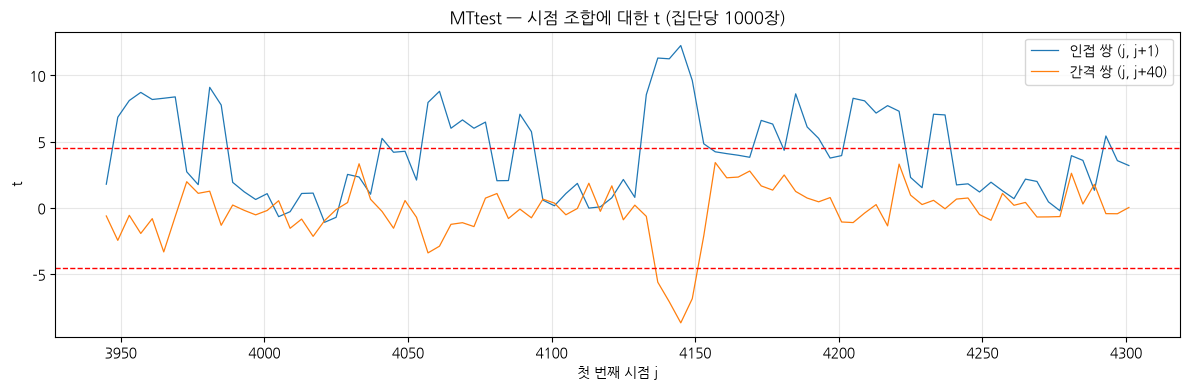

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, v in res.items():
    ax.plot(idx, v, lw=0.9, label=name)
ax.axhline(4.5, color="r", ls="--", lw=1); ax.axhline(-4.5, color="r", ls="--", lw=1)
ax.set_xlabel("첫 번째 시점 j"); ax.set_ylabel("t")
ax.set_title("MTtest — 시점 조합에 대한 t (집단당 %d장)" % n_rk)
ax.legend(); ax.grid(True, alpha=0.3); fig.tight_layout(); plt.show()

---
## 2. 1차 `Ttest` 와 나란히 보기

같은 구간에서 1차 t 와 MTtest 결과를 겹쳐 보면, 조합 검정이 **1차와 다른 것을 보고 있는지**
아니면 단순히 1차 누설을 되비추는지 알 수 있다.

비보호 구현에서는 1차 누설이 워낙 커서 곱에도 그대로 묻어난다. 마스킹된 구현이라면
1차는 평평한데 MTtest 만 솟는 그림이 나온다 — 그것이 이 API 의 존재 이유다.

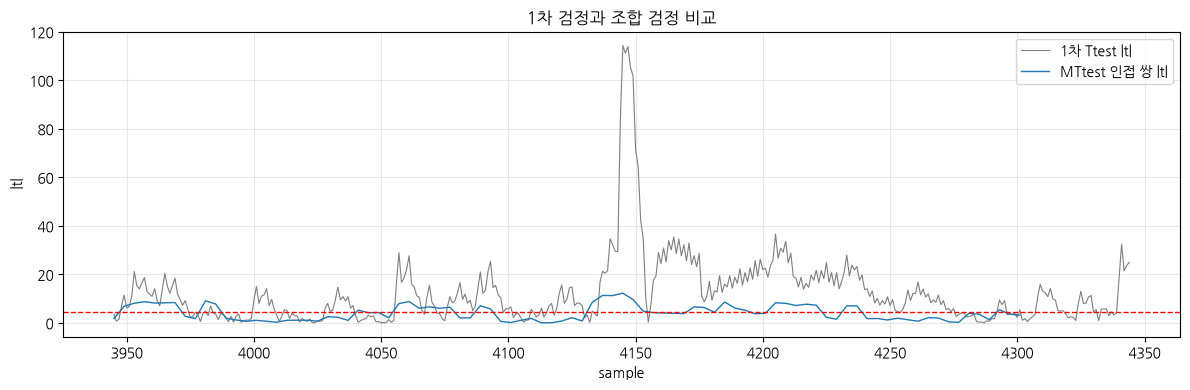

1차 max|t| (해당 구간) : 114.31
MTtest max|t|          : 12.25


In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(LO, HI), t1v[LO:HI], lw=0.8, label="1차 Ttest |t|", color="C7")
ax.plot(idx, np.abs(res["인접 쌍 (j, j+1)"]), lw=1.0, label="MTtest 인접 쌍 |t|")
ax.axhline(4.5, color="r", ls="--", lw=1)
ax.set_xlabel("sample"); ax.set_ylabel("|t|"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title("1차 검정과 조합 검정 비교")
fig.tight_layout(); plt.show()

print("1차 max|t| (해당 구간) : %.2f" % t1v[LO:HI].max())
print("MTtest max|t|          : %.2f" % np.nanmax(np.abs(res["인접 쌍 (j, j+1)"])))

---
## 3. 조합 수와 계산량

`pois` 의 열 수가 늘면 계산 시간과 메모리가 함께 는다. `d` 를 3 으로 올리면
조합 하나가 세 시점의 곱이 되어 후보가 더 빨리 폭발한다.

In [6]:
import time
print("조합 수    계산 시간")
for step in (16, 8, 4, 2):
    ii = np.arange(LO, HI - LAG, step, dtype=np.uint32)
    pp = np.stack([ii, ii + 1]).astype(np.uint32)
    t0 = time.time()
    m = MTtest(d=2, pois=pp)
    m.fit_u(np.vstack([rk["t"], fk["t"]]),
            np.concatenate([np.zeros(n_rk, dtype=np.uint16), np.ones(n_fk, dtype=np.uint16)]))
    m.get_ttest()
    print("  %5d      %.2f 초" % (pp.shape[1], time.time() - t0))

조합 수    계산 시간


     23      0.36 초


     45      0.34 초


     90      0.34 초


    180      0.34 초


---
## 4. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 한 시점이 아니라 **시점 조합의 곱**에 대한 t-test |
| API | `MTtest(d, pois)` → `fit_u(traces, x)` → `get_ttest()` → `(n_pois,)` |
| `pois` | `(d, n_pois)` `uint32`. **열 하나가 검정 하나** |
| `x` | `(n,)` `uint16`, 0/1 |
| 쓰임 | 마스킹 구현처럼 1차에서 안 보이는 누설을 찾을 때 |
| 주의 | 조합 수가 곧 계산량. 후보 구간을 먼저 좁힌다 |

### 실패 시 점검

1. `pois` 를 `(n_pois, d)` 로 넣으면 뜻이 달라진다. **행이 차수, 열이 조합**이다.
2. dtype 이 `uint32` 가 아니면 거부된다.
3. 조합 수를 줄이려면 1차 `Ttest` 나 `SNR` 로 후보 구간을 먼저 좁힌다.

다음: `3.0.CPA.ipynb` — 프로파일링 없이 키를 복구한다.